In [10]:
import os
import gzip
import json
import collections
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import bisect
import subprocess
from typing import Dict, Any, List

# --- CONFIGURATION ---
SAMPLES_CSV = "training_complete_processed_metadata.csv"
THRESHOLDS_JSON = "training_results_indels/best_thresholds.json"
EXOME_BED_PATH = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed" 
BLACKLIST_BED = "../../resources/master_blacklist.bed"  
ARTEFACT_GENES_BED = "../../resources/master_blacklist.bed" 

# Load the thresholds optimized by Optuna
with open(THRESHOLDS_JSON) as f:
    config = json.load(f)
    THRESHOLDS = config["thresholds"]
    PON_FLAGS = config.get("pon_flags", {"use_cord_pon": True})

print(f"[INFO] Thresholds loaded. Analysis will evaluate {len(THRESHOLDS)} tunable features.")

[INFO] Thresholds loaded. Analysis will evaluate 39 tunable features.


In [11]:
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED not found: {bed_path}")
            return
        count = 0
        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip(): continue
                parts = line.strip().split()
                chrom, start, end = parts[0], int(parts[1]), int(parts[2])
                if chrom not in self.intervals: self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
                count += 1
        for chrom in self.intervals: self.intervals[chrom].sort(key=lambda x: x[0])
        print(f"[INFO] Loaded {count} regions for {self.name}.")

    def is_overlapped(self, chrom, pos):
        query_chrom = chrom
        if chrom not in self.intervals:
            if f"chr{chrom}" in self.intervals: query_chrom = f"chr{chrom}"
            elif chrom.startswith("chr") and chrom[3:] in self.intervals: query_chrom = chrom[3:]
            else: return False
        
        regions = self.intervals[query_chrom]
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx: break 
            if start <= query_idx < end: return True
        return False

# Initialize Lookups
exome_lookup = BedLookup(EXOME_BED_PATH, "Exome")
cluster_lookup = BedLookup(BLACKLIST_BED, "Cluster Blacklist")

[INFO] Loaded 283942 regions for Exome.
[INFO] Loaded 4208652 regions for Cluster Blacklist.


In [12]:
def parse_vcf_to_df(vcf_path, sample_id, thresholds, exome_lookup, cluster_lookup):
    data = []
    openf = gzip.open if vcf_path.endswith(".gz") else open

    total_variants = 0
    kept_variants = 0

    with openf(vcf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue

            total_variants += 1

            fields = line.strip().split("\t")
            chrom = fields[0]
            pos = int(fields[1])

            # --- Spatial filtering ---
            if not exome_lookup.is_overlapped(chrom, pos):
                continue
            if cluster_lookup.is_overlapped(chrom, pos):
                continue

            # Parse INFO
            info = {
                item.split("=")[0]: item.split("=")[1] if "=" in item else "Yes"
                for item in fields[7].split(";")
            }

            # --- Minimal features ---
            n_alt_sscs = int(info.get('N_ALT_SSCS', 0))
            n_total_sscs = int(info.get('N_TOTAL_SSCS', info.get('N_TOTAL', 0)))

            if n_total_sscs <= 0:
                continue

            vaf_sscs = n_alt_sscs / n_total_sscs

            # --- VAF filter ---
            if vaf_sscs > thresholds["germline_vaf_max"]:
                continue

            # Keep variant
            kept_variants += 1

            info.update({
                "CHROM": chrom,
                "POS": pos,
                "sample_id": sample_id,
                "VAF_SSCS": vaf_sscs
            })

            data.append(info)

    print(f"[INFO] {sample_id}: Total={total_variants} | Kept={kept_variants} | Removed={total_variants - kept_variants}")

    return pd.DataFrame(data)

all_dfs = []
samples_meta = pd.read_csv(SAMPLES_CSV)
for _, s in samples_meta.iterrows():
    print(f"Loading {s.sample_id}...", end="\r")
    df = parse_vcf_to_df(
    s.vcf_path,
    s.sample_id,
    THRESHOLDS,
    exome_lookup,
    cluster_lookup
)
    all_dfs.append(df)

df_raw = pd.concat(all_dfs, ignore_index=True)
# Convert numeric columns automatically
df_raw = df_raw.apply(pd.to_numeric, errors='ignore')
print(f"\n[INFO] Total variants loaded: {len(df_raw)}")

[INFO] 27YO_UDI5: Total=511 | Kept=296 | Removed=215
[INFO] 27YO_UDI6: Total=664 | Kept=394 | Removed=270
[INFO] UDI23_3x: Total=1488 | Kept=934 | Removed=554
[INFO] UDI24_3x: Total=1413 | Kept=910 | Removed=503
[INFO] UKCTOCS_UDI1: Total=855 | Kept=556 | Removed=299
[INFO] UKCTOCS_UDI2: Total=882 | Kept=578 | Removed=304
[INFO] UKCTOCS_UDI3: Total=741 | Kept=473 | Removed=268
[INFO] UKCTOCS_UDI4: Total=714 | Kept=479 | Removed=235
[INFO] UKCTOCS_UDI5: Total=577 | Kept=371 | Removed=206
[INFO] Cordblood_D1: Total=2362 | Kept=1457 | Removed=905
[INFO] Cordblood_H5: Total=1121 | Kept=676 | Removed=445
[INFO] Cordblood_H6: Total=933 | Kept=563 | Removed=370
[INFO] LEGACY_I1: Total=1114 | Kept=656 | Removed=458
[INFO] LEGACY_I2: Total=1399 | Kept=830 | Removed=569
[INFO] LEGACY_I3: Total=1242 | Kept=752 | Removed=490
[INFO] LEGACY_I4: Total=1306 | Kept=801 | Removed=505
[INFO] LEGACY_I5: Total=1252 | Kept=768 | Removed=484
[INFO] LEGACY_I6: Total=1418 | Kept=870 | Removed=548

[INFO] Total

/var/folders/bs/gv_lsqkn7s1_lfrf87g1nyhw0000gn/T/ipykernel_89959/3628898460.py:75: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_raw = df_raw.apply(pd.to_numeric, errors='ignore')


In [15]:
def label_indel_variant(row, thresholds, pon_flags):
    """
    Labels an INDEL variant as 1 (Pass) or 0 (Fail) and provides the first reason for failure.
    """
    # -----------------------
    # 1. Feature Extraction & Safe Defaults
    # -----------------------
    # Basic counts
    n_total_dcs = row.get('N_TOTAL', 0)
    n_total_sscs = row.get('N_TOTAL_SSCS', -1)
    if n_total_sscs == -1: n_total_sscs = n_total_dcs
    
    n_alt_sscs = row.get('N_ALT_SSCS', 0)
    vaf_sscs = n_alt_sscs / n_total_sscs if n_total_sscs > 0 else 0.0

    # INDEL Specifics
    alt_seq = row.get('ALT', '')
    indel_length = row.get('INDEL_LENGTH', 0)
    mean_inset_qual = row.get("MEAN_INSET_QUAL", 100.0) # Safe high default
    mean_del_anchor_qual = row.get("MEAN_DEL_ANCHOR_QUAL", 100.0) # Safe high default
    homopolymer_len = row.get("HOMOPOLYMER_LEN", 0)
    n_slippage_sscs = row.get("N_SLIPPAGE_SSCS", 0)
    
    # Quality Metrics
    asxs = row.get('AVG_ALT_ASXS', 100.0)
    mean_mapq = row.get('MEAN_ALT_MAPQ', 60.0)
    depth_percentile = row.get('DEPTH_PERCENTILE', 50)
    
    # Neighborhood / Sequence Context
    variants_20bp = row.get('VARIANTS_20BP', 0)
    variants_250bp = row.get('VARIANTS_250BP', 0)
    ref_entropy = row.get('REF_ENTROPY_40BP', 2.0)
    gc_content = row.get('GC_CONTENT', 0.5)
    dist_to_other_indel = row.get('DIST_TO_OTHER_INDEL', 1000)
    
    # Read/Alignment Architecture
    avg_alt_softclip = row.get('AVG_ALT_SOFTCLIP', 0.0)
    median_dist_softclip = row.get('MEDIAN_DIST_TO_SOFTCLIP', 1000)
    avg_alt_nm = row.get('AVG_ALT_EXCESS_NM', 0.0)
    avg_alt_n_count = row.get('AVG_ALT_N_COUNT', 0.0)
    rp_med = row.get('RP_MED_SSCS', 0.5)

    # Flags
    in_blacklist = row.get('IN_BLACKLIST', "No")
    in_cb_pon = row.get('IN_CB_PON', "No")

    # --- New Features ---
    sd_baseq = row.get("SD_BASEQ", 0.0) 
    avg_alt_read_mean_baseq = row.get("AVG_ALT_READ_MEAN_BQ", 100.0) 
    mean_ref_mapq = row.get("MEAN_REF_MAPQ", 60.0) 
    avg_ref_asxs = row.get("AVG_REF_ASXS", 100.0) 
    avg_altread_variants = row.get("AVG_ALTREAD_VARIANTS", 0.0) 
    avg_nonaltread_variants = row.get("AVG_NONALTREAD_VARIANTS", 0.0) 
    mean_insert = row.get("MEAN_INSERT", 250.0) 
    sd_insert = row.get("SD_INSERT", 0.0) 
    avg_read_position = row.get("AVG_READ_POSITION", 75.0) 
    avg_read_length = row.get("AVG_READ_LENGTH", 150.0) 
    rp_sd_sscs = row.get("RP_SD_SSCS", 10.0) 
    strand_bias_sscs = row.get("STRAND_BIAS_SSCS", 0.5) 

    # -----------------------
    # 2. Filtering Logic
    # -----------------------
    
    # A. Baseline Safety
    if n_total_sscs <= 0: return 0, "HARD_N_TOTAL_SSCS"
    if n_alt_sscs <= 1: return 0, "HARD_N_ALT_SSCS" 
    if indel_length > 0 and 'N' in str(alt_seq).upper(): return 0, "HARD_N_IN_INSERTION"
    
    if pon_flags.get("use_cord_pon", False) and in_cb_pon == "Yes": return 0, "FAIL_CORD_PON"
    if in_blacklist == "YES" or in_blacklist == "Yes": return 0, "FAIL_BLACKLIST"

    # B. Depth & Shared Quality
    if n_total_dcs < thresholds.get("n_total_min", 0): return 0, "FAIL_MIN_DEPTH"
    if depth_percentile > thresholds.get("depth_percentile_max", 100): return 0, "FAIL_DEPTH_PERCENTILE"
    if mean_mapq < thresholds.get("mean_mapq_min", 0): return 0, "FAIL_MAPQ"
    if asxs <= thresholds.get("asxs_min", 0): return 0, "FAIL_ASXS"

    # C. Split Quality Logic (Ins vs Del)
    is_ins = indel_length > 0
    is_del = indel_length < 0
    
    if is_ins and mean_inset_qual < thresholds.get('mean_inset_qual_min', 0): return 0, "FAIL_INSET_QUAL"
    elif is_del and mean_del_anchor_qual < thresholds.get('mean_del_anchor_qual_min', 0): return 0, "FAIL_DEL_ANCHOR_QUAL"
    elif not is_ins and not is_del: return 0, "FAIL_INDEL_LENGTH_ZERO"

    # D. Homopolymer Logic
    abs_len = abs(indel_length)
    if abs_len == 1 and homopolymer_len > thresholds.get("hp_max_1bp", 100): return 0, "FAIL_HP_1BP"
    elif abs_len > 1 and homopolymer_len > thresholds.get("hp_max_long", 100): return 0, "FAIL_HP_LONG"
    if n_slippage_sscs > thresholds.get("max_slippage_reads", 100): return 0, "FAIL_SLIPPAGE"

    # E. Alignment & Context
    if variants_20bp > thresholds.get("variants_20bp_max", 100): return 0, "FAIL_VARIANTS_20BP"
    if variants_250bp > thresholds.get("variants_250bp_max", 100): return 0, "FAIL_VARIANTS_250BP"
    if ref_entropy < thresholds.get("ref_entropy_min", 0): return 0, "FAIL_REF_ENTROPY"
    if avg_alt_softclip > thresholds.get("avg_alt_softclip_max", 100): return 0, "FAIL_AVG_ALT_SOFTCLIP"
    if median_dist_softclip < thresholds.get("dist_to_softclip_min", 0): return 0, "FAIL_DIST_TO_SOFTCLIP"
    if avg_alt_nm > thresholds.get("avg_alt_nm_max", 100): return 0, "FAIL_AVG_ALT_NM"

    # F. Additional Filters
    if gc_content < thresholds.get("gc_min", 0) or gc_content > thresholds.get("gc_max", 1): return 0, "FAIL_GC_CONTENT"
    if dist_to_other_indel < thresholds.get("min_dist_to_indel", 0): return 0, "FAIL_DIST_TO_OTHER_INDEL"
    if rp_med < thresholds.get("min_rp_med", 0) or rp_med > thresholds.get("max_rp_med", 1): return 0, "FAIL_RP_MED"
    if avg_alt_n_count > thresholds.get("max_n_count", 100): return 0, "FAIL_N_COUNT"

    # G. Germline
    if vaf_sscs > thresholds.get("germline_vaf_max", 1): return 0, "FAIL_GERMLINE_VAF"

    # H. New Features
    if sd_baseq > thresholds.get("sd_baseq_max", 100): return 0, "FAIL_SD_BASEQ"
    if avg_alt_read_mean_baseq < thresholds.get("avg_alt_read_mean_baseq_min", 0): return 0, "FAIL_AVG_ALT_READ_MEAN_BASEQ"
    if mean_ref_mapq < thresholds.get("mean_ref_mapq_min", 0): return 0, "FAIL_MEAN_REF_MAPQ"
    if avg_ref_asxs < thresholds.get("avg_ref_asxs_min", 0): return 0, "FAIL_AVG_REF_ASXS"

    if avg_altread_variants > thresholds.get("avg_altread_variants_max", 100): return 0, "FAIL_AVG_ALTREAD_VARIANTS"
    if avg_nonaltread_variants > thresholds.get("avg_nonaltread_variants_max", 100): return 0, "FAIL_AVG_NONALTREAD_VARIANTS"

    if mean_insert < thresholds.get("mean_insert_min", 0) or mean_insert > thresholds.get("mean_insert_max", 1000): return 0, "FAIL_MEAN_INSERT"
    if sd_insert > thresholds.get("sd_insert_max", 1000): return 0, "FAIL_SD_INSERT"
    if avg_read_position < thresholds.get("avg_read_position_min", 0) or avg_read_position > thresholds.get("avg_read_position_max", 150): return 0, "FAIL_AVG_READ_POSITION"
    if avg_read_length < thresholds.get("avg_read_length_min", 0): return 0, "FAIL_AVG_READ_LENGTH"

    # I. Conditional Filters (Strand Bias & RP SD)
    if n_alt_sscs >= thresholds.get("strand_bias_n_alt_min", 100):
        if strand_bias_sscs < thresholds.get("strand_bias_min", 0) or strand_bias_sscs > thresholds.get("strand_bias_max", 1): 
            return 0, "FAIL_STRAND_BIAS"

    if n_alt_sscs >= thresholds.get("rp_sd_min_alt", 100):
        if rp_sd_sscs < thresholds.get("rp_sd_min", 0): 
            return 0, "FAIL_RP_SD"

    return 1, "PASS"

# Apply labeling
print("[INFO] Labeling variants...")
labels_and_reasons = df_raw.apply(lambda row: label_indel_variant(row, THRESHOLDS, PON_FLAGS), axis=1)
df_raw['Target'], df_raw['Reason'] = zip(*labels_and_reasons)

print(f"Labeling complete. Pass: {sum(df_raw['Target'] == 1)} | Fail: {sum(df_raw['Target'] == 0)}")

[INFO] Labeling variants...
Labeling complete. Pass: 660 | Fail: 11704


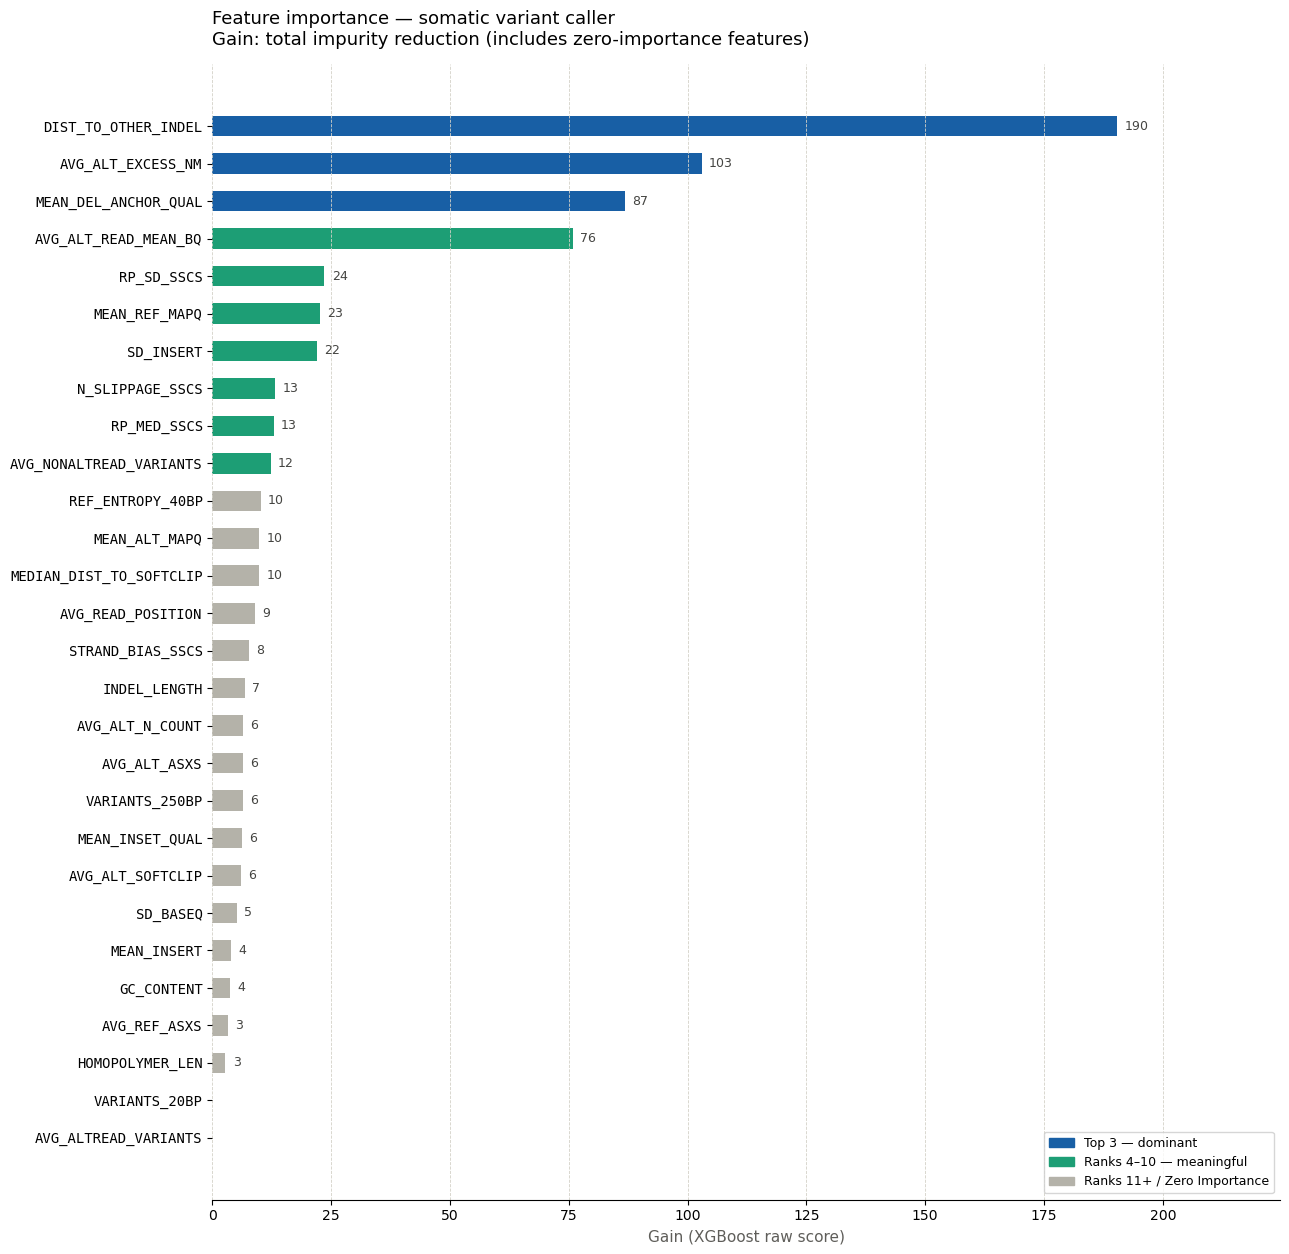

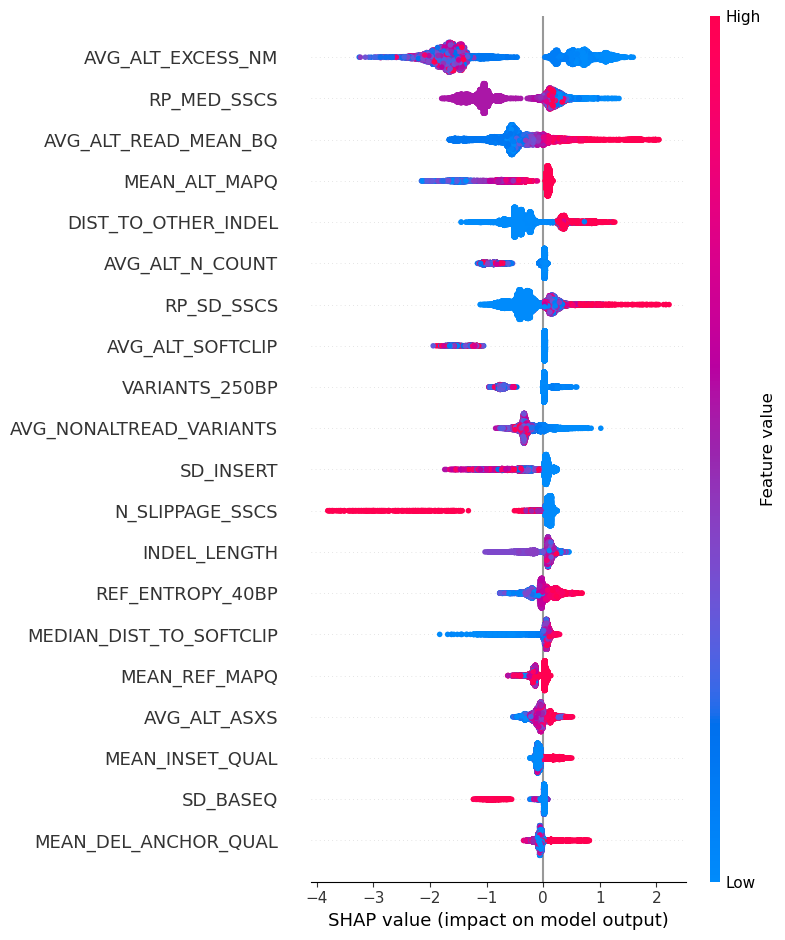

In [21]:
# =============================================================================
# Feature Importance Analysis — Final Cell
# Replaces the default xgb.plot_importance call with a polished matplotlib
# horizontal bar chart. SHAP summary plot is kept as-is.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xgboost as xgb
import shap

# --- Feature selection -----------------------------------------------------------
drop_cols = [
    'sample_id', 'CHROM', 'POS', 'Target', 'Reason',
    'VAF_DCS', 'VAF_SSCS', 'N_ALT', 'N_TOTAL', 'N_ALT_SSCS', 'N_TOTAL_SSCS',
    'IN_ENCODE_BLACKLIST', 'IN_REPEATMASKER', 'IN_CB_PON', 'IN_GNOMAD_COMMON', 'DEPTH_PERCENTILE', 'AVG_READ_LENGTH'
]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])
X = X.select_dtypes(include=[np.number])
y = df_raw['Target']

# --- Train model -----------------------------------------------------------------
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
)
model.fit(X, y)

# =============================================================================
# Visualization 1 — Polished Gain Importance (Includes 0-Importance Features)
# =============================================================================

# 1. Get the raw scores from the model
raw_importance = model.get_booster().get_score(importance_type='gain')

# 2. Map scores to ALL columns in X, filling missing ones with 0
# This ensures VARIANTS_20BP and others show up at the bottom
imp = (
    pd.Series(raw_importance)
    .reindex(X.columns, fill_value=0) 
    .sort_values(ascending=True)   # Smallest (0) at the bottom for hbar
)

N = len(imp)

# --- Colour tiers -------------------------------------------------------
COLOUR_TOP    = '#185FA5'   # deep blue
COLOUR_MID    = '#1D9E75'   # teal-green
COLOUR_MINOR  = '#B4B2A9'   # warm gray

def assign_colour(rank_from_top):
    if rank_from_top < 3:
        return COLOUR_TOP
    elif rank_from_top < 10:
        return COLOUR_MID
    else:
        return COLOUR_MINOR

# N-1-i ensures we rank from the largest value down
colours = [assign_colour(N - 1 - i) for i in range(N)]

# --- Layout -------------------------------------------------------------
bar_height   = 0.55
fig_height   = max(8, N * 0.38 + 2.0) # Height scales with number of features
fig, ax = plt.subplots(figsize=(13, fig_height))

bars = ax.barh(
    y=np.arange(N),
    width=imp.values,
    height=bar_height,
    color=colours,
    linewidth=0,
)

# Inline value labels — show for features with importance > 0
max_val = imp.values.max()
for bar, val in zip(bars, imp.values):
    if val > 0: # Don't clutter the 0-importance bars with "0" text
        ax.text(
            val + max_val * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}',
            va='center', ha='left',
            fontsize=9, color='#444441',
        )

# Feature name labels
ax.set_yticks(np.arange(N))
ax.set_yticklabels(imp.index, fontsize=10, fontfamily='monospace')

# Formatting styling
ax.set_xlabel('Gain (XGBoost raw score)', fontsize=11, color='#5F5E5A')
ax.set_title(
    "Feature importance — somatic variant caller\n"
    "Gain: total impurity reduction (includes zero-importance features)",
    fontsize=13, fontweight='normal', pad=14, loc='left',
)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.6, linestyle='--')

# Extend x-axis slightly
ax.set_xlim(0, max_val * 1.18)

# Legend
legend_handles = [
    mpatches.Patch(color=COLOUR_TOP,   label='Top 3 — dominant'),
    mpatches.Patch(color=COLOUR_MID,   label='Ranks 4–10 — meaningful'),
    mpatches.Patch(color=COLOUR_MINOR, label='Ranks 11+ / Zero Importance'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# Visualization 2 — SHAP Directionality (unchanged)
# =============================================================================

explainer  = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

In [20]:
# Get all features used in the dataframe
all_features = set(X.columns)

# Get features that actually appear in the model
used_features = set(model.get_booster().get_score(importance_type='gain').keys())

# The ones that didn't make the cut:
ignored_features = all_features - used_features
print(f"Features with zero importance: {ignored_features}")

Features with zero importance: {'VARIANTS_20BP', 'AVG_ALTREAD_VARIANTS'}
